### Setup envs

In [1]:
import os
import logging
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_recommenders as tfrs

### Model definition

In [2]:
class UserModel(tf.keras.Model):

	def __init__(self, conf):
		super().__init__()

		self.gender_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.StringLookup(
					vocabulary = conf['unique_genders'], mask_token = None
				),
				tf.keras.layers.Embedding(len(conf['unique_genders']) + 1, 4),
			]
		)

		self.lang_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.StringLookup(
					vocabulary = conf['unique_langs'], mask_token = None
				),
				tf.keras.layers.Embedding(len(conf['unique_langs']) + 1, 10),
			]
		)

		self.country_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.StringLookup(
					vocabulary = conf['unique_countries'], mask_token = None
				),
				tf.keras.layers.Embedding(len(conf['unique_countries']) + 1, 10),
			]
		)

		self.network_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.StringLookup(
					vocabulary = conf['unique_networks'], mask_token = None
				),
				tf.keras.layers.Embedding(len(conf['unique_networks']) + 1, 4),
			]
		)

		age_boundaries = np.array(conf['age_boundaries'])
		self.viewer_age_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.Discretization(age_boundaries.tolist()),
				tf.keras.layers.Embedding(len(age_boundaries), 2)
			]
		)

		self.centroids = tf.constant(conf['centroids'])
		self.viewer_lat_long_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.TextVectorization(
					standardize = None, split = self.classify,
					vocabulary = [str(i) for i in range(len(self.centroids))],
					max_tokens = len(self.centroids) + 2
				),
				tf.keras.layers.Embedding(len(self.centroids) + 2, 2),
			]
		)

	@tf.function()
	def call(self, inputs):
		return tf.concat(
			[
				self.gender_embedding(inputs["viewer_gender"]),
				self.lang_embedding(inputs["viewer_lang"]),
				self.country_embedding(inputs["viewer_country"]),
				self.network_embedding(inputs["viewer_network"]),
				self.viewer_age_embedding(inputs["viewer_age"]),
				self.viewer_lat_long_embedding(inputs["viewer_lat_long"]),
			], axis = 1
		)

	@tf.keras.utils.register_keras_serializable()
	def classify(self, pair):
		"""
        given a datapoint, compute the cluster closest to the datapoint. Return the cluster ID of that cluster.
        :param pair:
        :return: cluster ID
        """
		str_data = tf.strings.split(pair, sep = ",").values
		str_data = tf.map_fn(lambda x: tf.strings.regex_replace(x, "b'", ""), str_data)
		datapoints = tf.map_fn(lambda x: tf.strings.to_number(x), str_data, dtype = (tf.float32))
		datapoints = tf.reshape(datapoints, [-1, 2])

		expanded_centroids = tf.expand_dims(self.centroids, 1)
		expanded_vectors = tf.expand_dims(datapoints, 0)
		distances = tf.reduce_sum(tf.square(tf.subtract(expanded_vectors, expanded_centroids)), 2)
		clusters = tf.math.argmin(distances)
		return tf.strings.as_string(clusters)

In [3]:
class QueryModel(tf.keras.Model):

	def __init__(self, conf):
		super().__init__()

		# We first use the user model for generating embeddings.
		self.embedding_model = UserModel(conf)
		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.BatchNormalization(),
				tf.keras.layers.Dense(32),
			]
		)

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [4]:
class BroadcasterModel(tf.keras.Model):

	def __init__(self, conf):
		super().__init__()

		self.broadcaster_embedding = tf.keras.Sequential(
			[
				tf.keras.layers.experimental.preprocessing.StringLookup(
					vocabulary = conf['unique_broadcasters'], mask_token = None
				),
				tf.keras.layers.Embedding(len(conf['unique_broadcasters']) + 1, conf['broadcaster_embedding_dimension'])
			]
		)

	def call(self, broadcaster):
		return tf.concat(
			[
				self.broadcaster_embedding(broadcaster),
			], axis = 1
		)

In [5]:
class CandidateModel(tf.keras.Model):

	def __init__(self, conf):
		super().__init__()

		self.embedding_model = BroadcasterModel(conf)

		self.dense_layers = tf.keras.Sequential(
			[
				tf.keras.layers.Dense(32, activation = 'relu', kernel_regularizer = tf.keras.regularizers.L2(0.0001)),
				tf.keras.layers.BatchNormalization(),
				tf.keras.layers.Dropout(0.5),
				tf.keras.layers.Dense(32)
			]
		)

	def call(self, inputs):
		feature_embedding = self.embedding_model(inputs)
		return self.dense_layers(feature_embedding)

In [6]:
class RankingModel(tf.keras.Model):

	def __init__(self, conf):
		super().__init__()
		self.embedding_dimension = conf["broadcaster_embedding_dimension"]

		# Compute predictions.
		self.ratings = tf.keras.Sequential(
			[
				# Learn multiple dense layers.
				tf.keras.layers.Dense(self.embedding_dimension * 4, activation = "relu"),
				tf.keras.layers.BatchNormalization(),
				tf.keras.layers.Dense(self.embedding_dimension, activation = "relu"),
				tf.keras.layers.BatchNormalization(),
				# Make rating predictions in the final layer.
				tf.keras.layers.Dense(1)
			]
		)

	def call(self, inputs):
		query_embeddings, positive_broadcaster_embeddings = inputs
		return self.ratings(tf.concat([query_embeddings, positive_broadcaster_embeddings], axis = 1))

### Load data

In [7]:
def load_data_file_cold(file, stats):
	print('loading file:' + file)
	training_df = pd.read_csv(
		file,
		skiprows = [0],
		names = ["viewer",
		         "broadcaster",
		         "viewer_age",
		         "viewer_gender",
		         "viewer_longitude",
		         "viewer_latitude",
		         "viewer_lang",
		         "viewer_country",
		         "broadcaster_age",
		         "broadcaster_gender",
		         "broadcaster_longitude",
		         "broadcaster_latitude",
		         "broadcaster_lang",
		         "broadcaster_country",
		         "duration",
		         "viewer_network",
		         "broadcaster_network",
		         "count"],
		dtype = {
			'viewer': np.unicode,
			'broadcaster': np.unicode,
			'viewer_age': np.single,
			'viewer_gender': np.unicode,
			'viewer_longitude': np.single,
			'viewer_latitude': np.single,
			'viewer_lang': np.unicode,
			'viewer_country': np.unicode,
			'broadcaster_age': np.single,
			'broadcaster_longitude': np.single,
			'broadcaster_latitude': np.single,
			'broadcaster_lang': np.unicode,
			'broadcaster_country': np.unicode,
			'duration': np.single,
			'viewer_network': np.unicode,
			'broadcaster_network': np.unicode,
			'count': np.unicode,
		}
	)

	values = {
		'viewer': 'unknown',
		'broadcaster': 'unknown',
		'viewer_age': 30,
		'viewer_gender': 'unknown',
		'viewer_longitude': 0,
		'viewer_latitude': 0,
		'viewer_lang': 'unknown',
		'viewer_country': 'unknown',
		'broadcaster_age': 30,
		'broadcaster_longitude': 0,
		'broadcaster_latitude': 0,
		'broadcaster_lang': 'unknown',
		'broadcaster_country': 'unknown',
		'duration': 0,
		'viewer_network': 'unknown',
		'broadcaster_network': 'unknown',
		"viewer_lat_long": tf.constant(["40.36393,-74.89611"]),
		'count': '1'
	}

	training_df = training_df.sample(frac = 0.1)
	training_df.fillna(value = values, inplace = True)
	training_df['viewer_lat_long'] = training_df[['viewer_latitude', 'viewer_longitude']].apply(
		lambda x: '{},{}'.format(x[0], x[1]), axis = 1
	)
	training_df['duration'] = training_df['duration'].apply(lambda x: np.log(1+x))
	print(training_df.head(10))
	print(training_df.iloc[-10:])
	# stats.send_stats('data-size', len(training_df.index))
	return training_df

In [8]:
def load_training_data_cold(file, stats):
	ratings_df = load_data_file_cold(file, stats)
	print('creating data set')
	training_ds = (
		tf.data.Dataset.from_tensor_slices(
			({
				"viewer": tf.cast(
					ratings_df['viewer'].values,
					tf.string
				),
				"viewer_gender": tf.cast(
					ratings_df['viewer_gender'].values,
					tf.string
				),
				"viewer_lang": tf.cast(
					ratings_df['viewer_lang'].values,
					tf.string
				),
				"viewer_country": tf.cast(
					ratings_df['viewer_country'].values,
					tf.string
				),
				"viewer_age": tf.cast(
					ratings_df['viewer_age'].values,
					tf.int32
				),
				"viewer_longitude": tf.cast(
					ratings_df['viewer_longitude'].values,
					tf.float16
				),
				"viewer_latitude": tf.cast(
					ratings_df['viewer_latitude'].values,
					tf.float16
				),
				"broadcaster": tf.cast(
					ratings_df['broadcaster'].values,
					tf.string
				),
				"viewer_network": tf.cast(
					ratings_df['viewer_network'].values,
					tf.string
				),
				"broadcaster_network": tf.cast(
					ratings_df['broadcaster_network'].values,
					tf.string
				),
				"duration": tf.cast(
					ratings_df['duration'].values,
					tf.float16
                ),
				"viewer_lat_long": tf.cast(
					ratings_df['viewer_lat_long'].values,
					tf.string
				),
			})
		))

	return training_ds

In [9]:
def prepare_training_data_cold(train_ds):
	print('prepare_training_data')
	training_ds = train_ds.cache().map(
		lambda x: {
			"broadcaster": x["broadcaster"],
			"viewer": x["viewer"],
			"viewer_gender": x["viewer_gender"],
			"viewer_lang": x["viewer_lang"],
			"viewer_country": x["viewer_country"],
			"viewer_age": x["viewer_age"],
			"viewer_longitude": x["viewer_longitude"],
			"viewer_latitude": x["viewer_latitude"],
			"viewer_network": x["viewer_network"],
			"broadcaster_network": x["broadcaster_network"],
			"duration": x["duration"],
			"viewer_lat_long": x["viewer_lat_long"],
		}, num_parallel_calls = tf.data.AUTOTUNE,
		deterministic = False
	)

	print('done prepare_training_data')
	return training_ds


In [10]:
def get_broadcaster_data_set(train_ds):
    broadcasters = train_ds.cache().map(lambda x: x["broadcaster"], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    broadcasters_ds = tf.data.Dataset.from_tensor_slices(
        np.unique(list(broadcasters.as_numpy_iterator())))
    return broadcasters_ds

In [11]:
training_dataset = load_training_data_cold("csv/2022-01-12.csv", "")

loading file:csv/2022-01-12.csv
                                                  viewer  \
1146245  c0 93 d8 f0 e6 78 72 e3 4a 73 ef dd d3 41 f7 aa   
7005361  a2 be 01 70 c2 4b c5 54 b4 05 37 e3 7c e9 a5 db   
5837250  e3 72 2a 9d 66 1e e0 64 43 c5 7f 70 a2 52 9a 4e   
2086714  57 2d 40 03 74 1f e9 8a 66 90 36 cc 73 f6 2f e3   
4801097  dd 90 f2 51 b0 26 e0 be ed 6e a2 fa 3f 5f ed f7   
4860019  3e 73 84 98 eb 31 6a e1 b3 2d 5a 19 e4 28 b0 5b   
6643459  5d bf 69 d9 51 c6 cb 3b 7c 26 06 e4 16 9a bb 72   
4005826  b8 9e 86 10 2d b0 f7 94 c2 3f 78 ee 07 43 60 6b   
9485544  4a 9b 7d cb 65 e7 1a 8d ce 4a 8f cc 95 1b 03 32   
3957810  68 b7 d2 28 fb f8 64 71 0a f5 ae 31 7f d6 11 fe   

                                             broadcaster  viewer_age  \
1146245  0a 7a 53 5a f9 92 0a 72 b1 e5 dc 4b cf 90 64 1b        26.0   
7005361  fa 45 3e 31 1d 08 67 9d 8e 9d 56 a8 36 57 74 6e        24.0   
5837250  ad 99 2b 2c 40 a9 67 b1 40 d2 87 0b 5e 68 4f 8c        27.0   
2086714  cd 37 fa d

In [12]:
train = prepare_training_data_cold(training_dataset)

prepare_training_data
done prepare_training_data


In [13]:
broadcasters_data_set = get_broadcaster_data_set(training_dataset)

### Prepare model conf

In [14]:
def get_list(training_data, key):
    return training_data.batch(1_000_000).map(lambda x: x[key], num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)


def get_unique_list(data):
    return np.unique(np.concatenate(list(data)))

In [15]:
user_genders = get_list(train, 'viewer_gender')

In [16]:
user_langs = get_list(train, 'viewer_lang')

In [17]:
user_countries = get_list(train, 'viewer_country')

In [18]:
viewer_age = get_list(train, 'viewer_age')

In [19]:
user_networks = get_list(train, 'viewer_network')

### derive input dims

In [20]:
unique_user_genders = get_unique_list(user_genders)

In [21]:
len(unique_user_genders)

3

In [22]:
unique_user_langs = get_unique_list(user_langs)

In [23]:
len(unique_user_langs)

65

In [24]:
unique_user_countries = get_unique_list(user_countries)

In [25]:
len(unique_user_countries)

178

In [26]:
unique_user_networks = get_unique_list(user_networks)

In [27]:
len(unique_user_networks)

5

In [28]:
broadcaster_ids = get_list(train, 'broadcaster')

In [29]:
unique_broadcasters = get_unique_list(broadcaster_ids)

In [30]:
len(unique_broadcasters)

81391

In [31]:
model_config = {
    "top_k": 1999,
	"broadcaster_embedding_dimension": 64,
	"batch_size": 4096,
	"learning_rate": 0.1,
	"epochs": 30,
	"patience": 3,
	"age_boundaries": [18, 25, 30, 35, 40, 45, 50, 55, 60, 65, float("inf")],
	"centroids": [[36.68147669256268, -82.8910274009993],
	              [23.22243322909555, 78.23027450833709],
	              [50.04997682638993, 0.22379313938744885],
	              [37.9309447099281, -117.00741350764692],
	              [-32.795864819917725, 148.7159172660312],
	              [-18.570548393114084, -54.280255665692565],
	              [13.921140442819565, 116.38740315555172],
	              [29.78951080730802, 40.279515865947936]]
}

# ### query model

cold_start_conf = {
	**model_config, **{
		"unique_genders": unique_user_genders,
		"unique_langs": unique_user_langs,
		"unique_countries": unique_user_countries,
		"unique_networks": unique_user_networks,
		"unique_broadcasters": unique_broadcasters,
	}
}

In [32]:
cold_start_conf

{'top_k': 1999,
 'broadcaster_embedding_dimension': 64,
 'batch_size': 4096,
 'learning_rate': 0.1,
 'epochs': 30,
 'patience': 3,
 'age_boundaries': [18, 25, 30, 35, 40, 45, 50, 55, 60, 65, inf],
 'centroids': [[36.68147669256268, -82.8910274009993],
  [23.22243322909555, 78.23027450833709],
  [50.04997682638993, 0.22379313938744885],
  [37.9309447099281, -117.00741350764692],
  [-32.795864819917725, 148.7159172660312],
  [-18.570548393114084, -54.280255665692565],
  [13.921140442819565, 116.38740315555172],
  [29.78951080730802, 40.279515865947936]],
 'unique_genders': array([b'female', b'male', b'unknown'], dtype=object),
 'unique_langs': array([b'ar', b'az', b'bg', b'bn', b'bs', b'ca', b'co', b'cs', b'da',
        b'de', b'el', b'en', b'es', b'et', b'eu', b'fa', b'fi', b'fr',
        b'gl', b'gu', b'he', b'hi', b'hr', b'hu', b'id', b'in', b'it',
        b'iw', b'ja', b'ka', b'km', b'ko', b'lo', b'lt', b'lv', b'mk',
        b'ml', b'mr', b'ms', b'my', b'nb', b'ne', b'nl', b'ny', b'p

### query model

In [33]:
query_model = QueryModel(cold_start_conf)

### broadcaster model

In [34]:
candidate_model = CandidateModel(cold_start_conf)

### Candidate / Ranking model

In [35]:
ranking_model = RankingModel(cold_start_conf)

### Loss and metrics

In [36]:
ranking_task = tfrs.tasks.Ranking(
  loss = tf.keras.losses.MeanSquaredError(),
  metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [37]:
retrieval_task = tfrs.tasks.Retrieval(
    metrics=tfrs.metrics.FactorizedTopK(
        candidates=broadcasters_data_set.batch(128).map(candidate_model)
    )
)

In [38]:
from typing import Dict, Text

In [39]:
class MultiTasks(tfrs.models.Model):

	def __init__(self, candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight,
	             retrieval_weight):
		super().__init__()

		self.query_model: tf.keras.Model = query_model
		self.candidate_model: tf.keras.Model = candidate_model
		self.ranking_model: tf.keras.Model = ranking_model
		self.ranking_task = ranking_task
		self.retrieval_task = retrieval_task

		# The loss weights.
		self.ranking_weight = ranking_weight
		self.retrieval_weight = retrieval_weight

	def train_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
		with tf.GradientTape() as tape:
			query_embeddings = self.query_model(
				{
					"viewer_gender": features["viewer_gender"],
					"viewer_lang": features["viewer_lang"],
					"viewer_country": features["viewer_country"],
					"viewer_age": features["viewer_age"],
					"viewer_network": features["viewer_network"],
					"viewer_latitude": features["viewer_latitude"],
					"viewer_longitude": features["viewer_longitude"],
					"viewer_lat_long": features["viewer_lat_long"],
				}
			)
			positive_broadcaster_embeddings = self.candidate_model(
				features["broadcaster"]
			)

			labels = features["duration"]
			ranking_predictions = self.ranking_model(
				(query_embeddings, positive_broadcaster_embeddings)
			)
			ranking_loss = self.ranking_task(
				labels = labels,
				predictions = ranking_predictions,
			)

			retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)

			regularization_loss = sum(self.losses)

			total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss

		gradients = tape.gradient(total_loss, self.trainable_variables)
		self.optimizer.apply_gradients(
			zip(gradients, self.trainable_variables)
		)

		metrics = {metric.name: metric.result() for metric in self.metrics}
		metrics["loss"] = ranking_loss
		metrics["regularization_loss"] = regularization_loss
		metrics["total_loss"] = total_loss

		return metrics

	def test_step(self, features: Dict[Text, tf.Tensor]) -> tf.Tensor:
		labels = features["duration"]

		query_embeddings = self.query_model(
			{
				"viewer_gender": features["viewer_gender"],
				"viewer_lang": features["viewer_lang"],
				"viewer_country": features["viewer_country"],
				"viewer_age": features["viewer_age"],
				"viewer_network": features["viewer_network"],
				"viewer_latitude": features["viewer_latitude"],
				"viewer_longitude": features["viewer_longitude"],
				"viewer_lat_long": features["viewer_lat_long"],
			}
		)
		positive_broadcaster_embeddings = self.candidate_model(
			features["broadcaster"]
		)

		rating_predictions = self.ranking_model(
			(query_embeddings, positive_broadcaster_embeddings)
		)

		# The task computes the loss and the metrics.
		ranking_loss = self.ranking_task(labels = labels, predictions = rating_predictions)

		retrieval_loss = self.retrieval_task(query_embeddings, positive_broadcaster_embeddings)

		regularization_loss = sum(self.losses)

		total_loss = regularization_loss + self.ranking_weight * ranking_loss + self.retrieval_weight * retrieval_loss

		metrics = {metric.name: metric.result() for metric in self.metrics}
		metrics["loss"] = ranking_loss + retrieval_loss
		metrics["regularization_loss"] = regularization_loss
		metrics["total_loss"] = total_loss
		return metrics

In [40]:
ranking_weight = 0
retrieval_weight = 1

In [41]:
model = MultiTasks(
    candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight
)

In [42]:
tf.config.run_functions_eagerly(True)

In [43]:
model.compile(
        optimizer = tf.keras.optimizers.Adagrad(learning_rate = cold_start_conf["learning_rate"]),
        run_eagerly = True
    )

In [44]:
tf.random.set_seed(42)
shuffled = train.shuffle(100_000, seed=42, reshuffle_each_iteration=True)
train_ds = shuffled.take(80_000)
test_ds = shuffled.skip(80_000).take(20_000)
cached_train = train_ds.shuffle(100_000).batch(cold_start_conf["batch_size"]).cache().prefetch(tf.data.experimental.AUTOTUNE)
cached_test = test_ds.batch(cold_start_conf["batch_size"]).cache()

In [45]:
# model.fit(train_ds, epochs=epochs)
callback = tf.keras.callbacks.EarlyStopping(
    monitor = "total_loss",
    patience = cold_start_conf["patience"],
    verbose = 1,
    restore_best_weights = True
)
hist = model.fit(
    cached_train,
    epochs = cold_start_conf["epochs"],
    validation_data = cached_test,
    validation_freq = 1,
    callbacks = [callback]
    )

Epoch 1/30
Instructions for updating:
Use fn_output_signature instead
Instructions for updating:
The `validate_indices` argument has no effect. Indices are always validated on CPU and never validated on GPU.


/Users/lhuang/opt/miniconda3/lib/python3.9/site-packages/tensorflow/python/data/ops/dataset_ops.py:3703: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable.debug_mode()`.
  warnings.warn(


 9/20 [============>.................] - ETA: 2:01 - root_mean_squared_error: 4.4435 - factorized_top_k/top_1_categorical_accuracy: 5.4253e-05 - factorized_top_k/top_5_categorical_accuracy: 6.7817e-04 - factorized_top_k/top_10_categorical_accuracy: 0.0010 - factorized_top_k/top_50_categorical_accuracy: 0.0041 - factorized_top_k/top_100_categorical_accuracy: 0.0073 - loss: 19.7448 - regularization_loss: 0.0082 - total_loss: 34156.3524WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - ETA: 0s - root_mean_squared_error: 4.4629 - factorized_top_k/top_1_categorical_accuracy: 5.0000e-05 - factorized_top_k/top_5_categorical_accuracy: 8.2500e-04 - factorized_top_k/top_10_categorical_accuracy: 0.0016 - factorized_top_k/top_50_categorical_accuracy: 0.0063 - factorized_top_k/top_100_categorical_accuracy: 0.0112 - loss: 19.9068 - regularization_loss: 0.0085 - total_loss: 33245.0955 WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 337s 17s/step - root_mean_squared_error: 4.4629 - factorized_top_k/top_1_categorical_accuracy: 5.0000e-05 - factorized_top_k/top_5_categorical_accuracy: 8.2500e-04 - factorized_top_k/top_10_categorical_accuracy: 0.0016 - factorized_top_k/top_50_categorical_accuracy: 0.0063 - factorized_top_k/top_100_categorical_accuracy: 0.0112 - loss: 19.8850 - regularization_loss: 0.0085 - total_loss: 32456.0562 - val_root_mean_squared_error: 4.4238 - val_factorized_top_k/top_1_categorical_accuracy: 1.5000e-04 - val_factorized_top_k/top_5_categorical_accuracy: 7.0000e-04 - val_factorized_top_k/top_10_categorical_accuracy: 0.0016 - val_factorized_top_k/top_50_categorical_accuracy: 0.0072 - val_factorized_top_k/top_100_categorical_accuracy: 0.0117 - val_loss: 29489.6406 - val_regularization_loss: 0.0090 - val_total_loss: 29469.9219
Epoch 2/30
 8/20 [===========>..................] - ETA: 2:22 - root_mean_squared_error: 4.4042 - factorized_top_k/top_1_categorical

...

20/20 [==============================] - 335s 17s/step - root_mean_squared_error: 4.2725 - factorized_top_k/top_1_categorical_accuracy: 0.0061 - factorized_top_k/top_5_categorical_accuracy: 0.0312 - factorized_top_k/top_10_categorical_accuracy: 0.0532 - factorized_top_k/top_50_categorical_accuracy: 0.1516 - factorized_top_k/top_100_categorical_accuracy: 0.2225 - loss: 18.2596 - regularization_loss: 0.0230 - total_loss: 23260.0801 - val_root_mean_squared_error: 4.3025 - val_factorized_top_k/top_1_categorical_accuracy: 0.0029 - val_factorized_top_k/top_5_categorical_accuracy: 0.0125 - val_factorized_top_k/top_10_categorical_accuracy: 0.0214 - val_factorized_top_k/top_50_categorical_accuracy: 0.0676 - val_factorized_top_k/top_100_categorical_accuracy: 0.1035 - val_loss: 29863.0176 - val_regularization_loss: 0.0230 - val_total_loss: 29844.3867


Epoch 29/30
11/20 [===============>..............] - ETA: 5:43 - root_mean_squared_error: 4.2643 - factorized_top_k/top_1_categorical_accuracy: 0.0066 - factorized_top_k/top_5_categorical_accuracy: 0.0330 - factorized_top_k/top_10_categorical_accuracy: 0.0555 - factorized_top_k/top_50_categorical_accuracy: 0.1553 - factorized_top_k/top_100_categorical_accuracy: 0.2253 - loss: 18.1846 - regularization_loss: 0.0232 - total_loss: 24310.6191WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 703s 36s/step - root_mean_squared_error: 4.2656 - factorized_top_k/top_1_categorical_accuracy: 0.0060 - factorized_top_k/top_5_categorical_accuracy: 0.0314 - factorized_top_k/top_10_categorical_accuracy: 0.0529 - factorized_top_k/top_50_categorical_accuracy: 0.1505 - factorized_top_k/top_100_categorical_accuracy: 0.2229 - loss: 18.1979 - regularization_loss: 0.0232 - total_loss: 23160.2171 - val_root_mean_squared_error: 4.2943 - val_factorized_top_k/top_1_categorical_accuracy: 0.0021 - val_factorized_top_k/top_5_categorical_accuracy: 0.0131 - val_factorized_top_k/top_10_categorical_accuracy: 0.0226 - val_factorized_top_k/top_50_categorical_accuracy: 0.0672 - val_factorized_top_k/top_100_categorical_accuracy: 0.1016 - val_loss: 30001.6309 - val_regularization_loss: 0.0233 - val_total_loss: 29983.0703


Epoch 30/30
11/20 [===============>..............] - ETA: 2:07 - root_mean_squared_error: 4.2617 - factorized_top_k/top_1_categorical_accuracy: 0.0064 - factorized_top_k/top_5_categorical_accuracy: 0.0342 - factorized_top_k/top_10_categorical_accuracy: 0.0561 - factorized_top_k/top_50_categorical_accuracy: 0.1549 - factorized_top_k/top_100_categorical_accuracy: 0.2266 - loss: 18.1625 - regularization_loss: 0.0234 - total_loss: 24255.4467WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 326s 16s/step - root_mean_squared_error: 4.2641 - factorized_top_k/top_1_categorical_accuracy: 0.0065 - factorized_top_k/top_5_categorical_accuracy: 0.0322 - factorized_top_k/top_10_categorical_accuracy: 0.0542 - factorized_top_k/top_50_categorical_accuracy: 0.1558 - factorized_top_k/top_100_categorical_accuracy: 0.2295 - loss: 18.1896 - regularization_loss: 0.0235 - total_loss: 23090.7686 - val_root_mean_squared_error: 4.2890 - val_factorized_top_k/top_1_categorical_accuracy: 0.0030 - val_factorized_top_k/top_5_categorical_accuracy: 0.0137 - val_factorized_top_k/top_10_categorical_accuracy: 0.0228 - val_factorized_top_k/top_50_categorical_accuracy: 0.0696 - val_factorized_top_k/top_100_categorical_accuracy: 0.1049 - val_loss: 30155.3359 - val_regularization_loss: 0.0236 - val_total_loss: 30136.8203


In [46]:
hist.history

{'root_mean_squared_error': [4.46293830871582,
  4.4096455574035645,
  4.412464141845703,
  4.394143104553223,
  4.396146774291992,
  4.391201972961426,
  4.38244104385376,
  4.372103691101074,
  4.360389709472656,
  4.355821132659912,
  4.351749420166016,
  4.341889381408691,
  4.339698791503906,
  4.333409309387207,
  4.332543849945068,
  4.33112096786499,
  4.325953483581543,
  4.3204569816589355,
  4.314394474029541,
  4.309236526489258,
  4.303652763366699,
  4.300460338592529,
  4.293941974639893,
  4.292652130126953,
  4.286795139312744,
  4.280544757843018,
  4.275981426239014,
  4.272461891174316,
  4.265573501586914,
  4.264124393463135],
 'factorized_top_k/top_1_categorical_accuracy': [4.999999873689376e-05,
  0.00036249999538995326,
  0.0002125000028172508,
  0.0005000000237487257,
  0.0005249999812804163,
  0.0005499999970197678,
  0.0005874999915249646,
  0.0006624999805353582,
  0.001025000005029142,
  0.0014875000342726707,
  0.0017750000115484,
  0.00215000007301569,
 

In [47]:
accuracy = hist.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Retrieval top-100 accuracy: {accuracy:.4f}.")

Retrieval top-100 accuracy: 0.2295.


In [48]:
root_mean_squared_error = hist.history["root_mean_squared_error"][-1]
print(f"Ranking RMSE: {root_mean_squared_error:.4f}.")

Ranking RMSE: 4.2641.


### Joint model

In [49]:
ranking_weight = 1
retrieval_weight = 1

In [50]:
joint_model = MultiTasks(
    candidate_model, query_model, ranking_model, ranking_task, retrieval_task, ranking_weight, retrieval_weight
)

In [51]:
joint_model.compile(
    optimizer = tf.keras.optimizers.Adagrad(learning_rate = cold_start_conf["learning_rate"]),
    run_eagerly = True
)

In [52]:
joint_model_history = joint_model.fit(
    cached_train,
    epochs = cold_start_conf["epochs"],
    validation_data = cached_test,
    validation_freq = 1,
    callbacks = [callback]
    )

Epoch 1/30
10/20 [==============>...............] - ETA: 2:06 - root_mean_squared_error: 26.6650 - factorized_top_k/top_1_categorical_accuracy: 0.0010 - factorized_top_k/top_5_categorical_accuracy: 0.0066 - factorized_top_k/top_10_categorical_accuracy: 0.0115 - factorized_top_k/top_50_categorical_accuracy: 0.0414 - factorized_top_k/top_100_categorical_accuracy: 0.0691 - loss: 711.0234 - regularization_loss: 0.0241 - total_loss: 41965.7035WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - ETA: 0s - root_mean_squared_error: 19.1143 - factorized_top_k/top_1_categorical_accuracy: 8.8750e-04 - factorized_top_k/top_5_categorical_accuracy: 0.0055 - factorized_top_k/top_10_categorical_accuracy: 0.0102 - factorized_top_k/top_50_categorical_accuracy: 0.0404 - factorized_top_k/top_100_categorical_accuracy: 0.0726 - loss: 356.8489 - regularization_loss: 0.0240 - total_loss: 34332.6110 WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 301s 15s/step - root_mean_squared_error: 19.1143 - factorized_top_k/top_1_categorical_accuracy: 8.8750e-04 - factorized_top_k/top_5_categorical_accuracy: 0.0055 - factorized_top_k/top_10_categorical_accuracy: 0.0102 - factorized_top_k/top_50_categorical_accuracy: 0.0404 - factorized_top_k/top_100_categorical_accuracy: 0.0726 - loss: 339.9696 - regularization_loss: 0.0240 - total_loss: 33330.8287 - val_root_mean_squared_error: 1.5367 - val_factorized_top_k/top_1_categorical_accuracy: 0.0012 - val_factorized_top_k/top_5_categorical_accuracy: 0.0087 - val_factorized_top_k/top_10_categorical_accuracy: 0.0159 - val_factorized_top_k/top_50_categorical_accuracy: 0.0450 - val_factorized_top_k/top_100_categorical_accuracy: 0.0721 - val_loss: 27740.6699 - val_regularization_loss: 0.0244 - val_total_loss: 27740.6934
Epoch 2/30
 9/20 [============>.................] - ETA: 11:29 - root_mean_squared_error: 1.4852 - factorized_top_k/top_1_categorical_accuracy

20/20 [==============================] - ETA: 0s - root_mean_squared_error: 1.4924 - factorized_top_k/top_1_categorical_accuracy: 0.0039 - factorized_top_k/top_5_categorical_accuracy: 0.0198 - factorized_top_k/top_10_categorical_accuracy: 0.0344 - factorized_top_k/top_50_categorical_accuracy: 0.1051 - factorized_top_k/top_100_categorical_accuracy: 0.1572 - loss: 2.2273 - regularization_loss: 0.0246 - total_loss: 25709.4739 WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 703s 36s/step - root_mean_squared_error: 1.4924 - factorized_top_k/top_1_categorical_accuracy: 0.0039 - factorized_top_k/top_5_categorical_accuracy: 0.0198 - factorized_top_k/top_10_categorical_accuracy: 0.0344 - factorized_top_k/top_50_categorical_accuracy: 0.1051 - factorized_top_k/top_100_categorical_accuracy: 0.1572 - loss: 2.2277 - regularization_loss: 0.0246 - total_loss: 25074.1799 - val_root_mean_squared_error: 1.5375 - val_factorized_top_k/top_1_categorical_accuracy: 0.0021 - val_factorized_top_k/top_5_categorical_accuracy: 0.0107 - val_factorized_top_k/top_10_categorical_accuracy: 0.0181 - val_factorized_top_k/top_50_categorical_accuracy: 0.0569 - val_factorized_top_k/top_100_categorical_accuracy: 0.0893 - val_loss: 27899.4492 - val_regularization_loss: 0.0250 - val_total_loss: 27899.4746
Epoch 3/30
 8/20 [===========>..................] - ETA: 2:30 - root_mean_squared_error: 1.4713 - factorized_top_k/top_1_categorical_accuracy: 0.0043

...

Epoch 18/30
11/20 [===============>..............] - ETA: 1:50 - root_mean_squared_error: 1.4386 - factorized_top_k/top_1_categorical_accuracy: 0.0075 - factorized_top_k/top_5_categorical_accuracy: 0.0388 - factorized_top_k/top_10_categorical_accuracy: 0.0658 - factorized_top_k/top_50_categorical_accuracy: 0.1799 - factorized_top_k/top_100_categorical_accuracy: 0.2640 - loss: 2.0695 - regularization_loss: 0.0279 - total_loss: 23324.4006WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 294s 15s/step - root_mean_squared_error: 1.4391 - factorized_top_k/top_1_categorical_accuracy: 0.0080 - factorized_top_k/top_5_categorical_accuracy: 0.0393 - factorized_top_k/top_10_categorical_accuracy: 0.0651 - factorized_top_k/top_50_categorical_accuracy: 0.1794 - factorized_top_k/top_100_categorical_accuracy: 0.2607 - loss: 2.0711 - regularization_loss: 0.0280 - total_loss: 22270.3099 - val_root_mean_squared_error: 1.4575 - val_factorized_top_k/top_1_categorical_accuracy: 0.0029 - val_factorized_top_k/top_5_categorical_accuracy: 0.0154 - val_factorized_top_k/top_10_categorical_accuracy: 0.0250 - val_factorized_top_k/top_50_categorical_accuracy: 0.0771 - val_factorized_top_k/top_100_categorical_accuracy: 0.1175 - val_loss: 30740.8086 - val_regularization_loss: 0.0280 - val_total_loss: 30740.8359


Epoch 19/30
11/20 [===============>..............] - ETA: 1:43 - root_mean_squared_error: 1.4362 - factorized_top_k/top_1_categorical_accuracy: 0.0079 - factorized_top_k/top_5_categorical_accuracy: 0.0402 - factorized_top_k/top_10_categorical_accuracy: 0.0678 - factorized_top_k/top_50_categorical_accuracy: 0.1861 - factorized_top_k/top_100_categorical_accuracy: 0.2662 - loss: 2.0628 - regularization_loss: 0.0281 - total_loss: 23274.1493WARNING:tensorflow:It looks like tf.function behavior was disabled, perhaps using tf.config.run_functions_eagerly. Vectorization primitives (e.g. tf.vectorized_map) require tf.function to work. These primitives will override the disable.


20/20 [==============================] - 287s 15s/step - root_mean_squared_error: 1.4357 - factorized_top_k/top_1_categorical_accuracy: 0.0081 - factorized_top_k/top_5_categorical_accuracy: 0.0394 - factorized_top_k/top_10_categorical_accuracy: 0.0655 - factorized_top_k/top_50_categorical_accuracy: 0.1809 - factorized_top_k/top_100_categorical_accuracy: 0.2598 - loss: 2.0603 - regularization_loss: 0.0281 - total_loss: 22217.2221 - val_root_mean_squared_error: 1.4563 - val_factorized_top_k/top_1_categorical_accuracy: 0.0032 - val_factorized_top_k/top_5_categorical_accuracy: 0.0162 - val_factorized_top_k/top_10_categorical_accuracy: 0.0262 - val_factorized_top_k/top_50_categorical_accuracy: 0.0764 - val_factorized_top_k/top_100_categorical_accuracy: 0.1164 - val_loss: 30915.0410 - val_regularization_loss: 0.0281 - val_total_loss: 30915.0684


Restoring model weights from the end of the best epoch.
Epoch 00019: early stopping


In [53]:
joint_model_history.history

{'root_mean_squared_error': [19.114288330078125,
  1.4923593997955322,
  1.4798996448516846,
  1.4584792852401733,
  1.4512810707092285,
  1.4505212306976318,
  1.4457799196243286,
  1.4483466148376465,
  1.4444795846939087,
  1.4475429058074951,
  1.4385331869125366,
  1.4431061744689941,
  1.4377778768539429,
  1.4415323734283447,
  1.437920093536377,
  1.43977952003479,
  1.4361339807510376,
  1.439118504524231,
  1.4357486963272095],
 'factorized_top_k/top_1_categorical_accuracy': [0.0008875000057742,
  0.003949999809265137,
  0.0049749999307096004,
  0.006162500008940697,
  0.006800000090152025,
  0.007249999791383743,
  0.007112499792128801,
  0.007499999832361937,
  0.008299999870359898,
  0.007362499833106995,
  0.008237499743700027,
  0.00795000046491623,
  0.008737499825656414,
  0.007724999915808439,
  0.007699999958276749,
  0.008449999615550041,
  0.008475000038743019,
  0.007987500168383121,
  0.008124999701976776],
 'factorized_top_k/top_5_categorical_accuracy': [0.00549

In [54]:
accuracy = joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-1]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.2598.


In [55]:
root_mean_squared_error = joint_model_history.history["root_mean_squared_error"][-1]
print(f"Ranking RMSE: {root_mean_squared_error:.4f}.")

Ranking RMSE: 1.4357.


In [56]:
idx = np.argmin(joint_model_history.history["total_loss"])
accuracy = joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"][idx]
print(f"Top-100 accuracy: {accuracy:.4f}.")

Top-100 accuracy: 0.2568.


In [57]:
root_mean_squared_error = joint_model_history.history["root_mean_squared_error"][idx]
print(f"Ranking RMSE: {root_mean_squared_error:.4f}.")

Ranking RMSE: 1.4398.


In [58]:
num_validation_runs = len(joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"])

In [59]:
num_validation_runs

19

In [60]:
old_num_validation_runs = len(hist.history["factorized_top_k/top_100_categorical_accuracy"])

In [61]:
old_num_validation_runs

30

In [62]:
runs = min(old_num_validation_runs, num_validation_runs)

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt

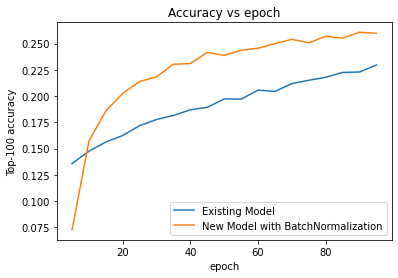

In [71]:
epochs = [(x + 1)* 5 for x in range(runs)]

plt.plot(epochs, hist.history["factorized_top_k/top_100_categorical_accuracy"][-runs:], label="Existing Model")
plt.plot(epochs, joint_model_history.history["factorized_top_k/top_100_categorical_accuracy"][-runs:], label="New Model with BatchNormalization")
plt.title("Accuracy vs epoch")
plt.xlabel("epoch")
plt.ylabel("Top-100 accuracy");
plt.legend()

In [65]:
def full_summary(layer):

    #check if this layer has layers
    if hasattr(layer, 'layers'):
        print('summary for ' + layer.name)
        layer.summary()
        print('\n\n')

        for l in layer.layers:
            full_summary(l)

In [66]:
full_summary(joint_model.query_model)

summary for query_model
Model: "query_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
user_model (UserModel)       multiple                  2544      
_________________________________________________________________
sequential_6 (Sequential)    (None, 32)                2240      
Total params: 4,784
Trainable params: 4,708
Non-trainable params: 76
_________________________________________________________________



summary for user_model
Model: "user_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (None, 4)                 16        
_________________________________________________________________
sequential_1 (Sequential)    (None, 10)                660       
_________________________________________________________________
sequential_2 (Sequential)    (None, 10)         

In [67]:
full_summary(model.candidate_model)

summary for candidate_model
Model: "candidate_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
broadcaster_model (Broadcast multiple                  5209088   
_________________________________________________________________
sequential_8 (Sequential)    (None, 32)                3264      
Total params: 5,212,352
Trainable params: 5,212,288
Non-trainable params: 64
_________________________________________________________________



summary for broadcaster_model
Model: "broadcaster_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_7 (Sequential)    (None, 64)                5209088   
Total params: 5,209,088
Trainable params: 5,209,088
Non-trainable params: 0
_________________________________________________________________



summary for sequential_7
Model: "sequential_7"
________________________

In [70]:
full_summary(model.ranking_model)

summary for ranking_model
Model: "ranking_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_9 (Sequential)    (None, 1)                 34433     
Total params: 34,433
Trainable params: 33,793
Non-trainable params: 640
_________________________________________________________________



summary for sequential_9
Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 256)               16640     
_________________________________________________________________
batch_normalization_2 (Batch (None, 256)               1024      
_________________________________________________________________
dense_5 (Dense)              (None, 64)                16448     
_________________________________________________________________
batch_normalization_3 (Batch (None, 6